# Cloud Optimized GeoTIFF Results Export with ras2cng

Generate result rasters (WSE, Depth, Velocity, Froude, Shear Stress, DxV) from HEC-RAS simulations, convert to Cloud Optimized GeoTIFF (COG), and optionally build raster PMTiles — all using [ras2cng](https://github.com/gpt-cmdr/ras2cng) and its `generate_result_maps()` function backed by RasStoreMapHelper.exe.

In [1]:
#!pip install --upgrade ras-commander ras2cng rasterio matplotlib

In [2]:
USE_LOCAL_SOURCE = False

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

from ras_commander import RasExamples, init_ras_project, RasCmdr, ras
from pathlib import Path
import numpy as np

import ras_commander
print(f"ras-commander: {ras_commander.__file__}")

import ras2cng
print(f"ras2cng: {ras2cng.__file__}")

PIP PACKAGE MODE: Loading installed ras-commander


2026-06-11 14:52:30 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.


ras-commander: <repo>\ras_commander\__init__.py


ras2cng: <symphony-dev>\Lib\site-packages\ras2cng\__init__.py


## Prerequisites

- **ras-commander** installed: `pip install ras-commander`
- **ras2cng** installed: `pip install ras2cng`
- **HEC-RAS installed** (Windows): RasStoreMapHelper.exe generates the rasters
- **rasterio** installed: `pip install rasterio` (for raster inspection and display)
- **matplotlib** installed: `pip install matplotlib` (for raster visualization)
- **Optional**: GDAL CLI for COG conversion (`gdal_translate`)

### What You'll Learn

- Generate result rasters from completed HEC-RAS simulations
- Produce WSE, Depth, Velocity, Froude, Shear Stress, and DxV raster layers
- Convert rasters to Cloud Optimized GeoTIFF (COG) format
- Inspect and display raster results in the notebook
- Understand the 11 available map types and when to use each

### How It Works

ras2cng's `generate_result_maps()` function wraps `RasProcess.store_maps()`, which deploys
HEC-RAS's native **RasStoreMapHelper.exe** to render simulation results to GeoTIFF rasters.
This is the same engine HEC-RAS uses internally — output matches native HEC-RAS exactly.

### Related Notebooks

- **960_cloud_native_geometry_export.ipynb** — Export geometry to GeoParquet (no HEC-RAS required)
- **961_cloud_native_results_export.ipynb** — Export vector results to GeoParquet with DuckDB
- **601_headless_stored_map_generation_rasmapper.ipynb** — RasProcess.store_maps() directly (lower-level API)

## Parameters

In [3]:
PROJECT_NAME = "BaldEagleCrkMulti2D"
RAS_VERSION = "6.6"
OUTPUT_DIR = Path("out/962_cloud_native_cog").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Available Map Types

ras2cng supports 11 result raster types via the `generate_result_maps()` function:

| Map Type | Parameter | Default | Description |
|----------|-----------|---------|-------------|
| Water Surface Elevation | `wse` | On | Absolute water surface elevation |
| Depth | `depth` | On | Water depth above ground |
| Velocity | `velocity` | On | Flow velocity magnitude |
| Froude Number | `froude` | Off | Subcritical/supercritical classification |
| Shear Stress | `shear_stress` | Off | Bed shear stress |
| Depth x Velocity | `depth_x_velocity` | Off | Hazard index (DxV) |
| Depth x Velocity² | `depth_x_velocity_sq` | Off | Force proxy (DxV²) |
| Inundation Boundary | `inundation_boundary` | Off | Flood extent polygon (shapefile) |
| Arrival Time | `arrival_time` | Off | Time water first arrives |
| Duration | `duration` | Off | Time area stays wet |
| Recession | `recession` | Off | Time water recedes |

WSE, Depth, and Velocity are enabled by default. Toggle others on/off as needed.

---

## Example 1: Core Result Rasters (WSE, Depth, Velocity)

Extract a project, run a simulation, then generate the three default result rasters as Cloud Optimized GeoTIFFs.

### Extract and Initialize Project

In [4]:
project_path = RasExamples.extract_project(PROJECT_NAME)
ras_obj = init_ras_project(project_path, RAS_VERSION)

print(f"Project: {project_path}")
print(f"Plans: {len(ras.plan_df)}")
print(f"Geometries: {len(ras.geom_df)}")
ras.plan_df[['plan_number', 'Plan Title', 'Geom File']].head()

2026-06-11 14:52:34 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to <repo>\examples\example_projects\BaldEagleCrkMulti2D


2026-06-11 14:52:34 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec-ras-install>\7.0\Ras.exe via filesystem (x86)


2026-06-11 14:52:34 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec-ras-install>\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-11 14:52:34 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at <hec-ras-install>\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-06-11 14:52:34 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at <hec-ras-install>\6.6\Ras.exe via filesystem (x86)


...

2026-06-11 14:52:34 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk | Folder: <repo>\examples\example_projects\BaldEagleCrkMulti2D


2026-06-11 14:52:34 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: <hec-ras-install>\6.6\Ras.exe


2026-06-11 14:52:34 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_plan() / clone_

Project: <repo>\examples\example_projects\BaldEagleCrkMulti2D
Plans: 11
Geometries: 10


,plan_number,Plan Title,Geom File
0,13,PMF with Multi 2D Areas,06
1,15,1d-2D Dambreak Refined Grid,08
2,17,2D to 1D No Dam,10
3,18,2D to 2D Run,11
4,19,SA to 2D Dam Break Run,12


### Run Simulation

Execute the first plan to generate results HDF files. Smart skip avoids re-running if results are current.

In [5]:
plan_number = ras.plan_df['plan_number'].iloc[0]
print(f"Running plan {plan_number}...")

try:
    RasCmdr.compute_plan(plan_number)
    print(f"Plan {plan_number} completed.")
except Exception as e:
    print(f"Execution failed: {e}")
    print("Continuing with any existing HDF files...")

2026-06-11 14:52:34 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: <repo>\examples\example_projects\BaldEagleCrkMulti2D


2026-06-11 14:52:34 - ras_commander.RasCmdr - INFO - Running HEC-RAS from the Command Line:


2026-06-11 14:52:34 - ras_commander.RasCmdr - INFO - Running command: "<hec-ras-install>\6.6\Ras.exe" -c "<repo>\examples\example_projects\BaldEagleCrkMulti2D\BaldEagleDamBrk.prj" "<repo>\examples\example_projects\BaldEagleCrkMulti2D\BaldEagleDamBrk.p13"


2026-06-11 14:52:34 - ras_commander.RasDialogWatchdog - INFO - DialogWatchdog started — polling every 1.5s for RAS dialog windows


Running plan 13...


2026-06-11 14:55:37 - ras_commander.RasCmdr - INFO - HEC-RAS execution completed for plan: 13


2026-06-11 14:55:37 - ras_commander.RasCmdr - INFO - Total run time for plan 13: 182.40 seconds


2026-06-11 14:55:37 - ras_commander.RasDialogWatchdog - INFO - DialogWatchdog stopped — no dialogs encountered


Plan 13 completed.


In [6]:
plan_hdfs = sorted(project_path.glob("*.p??.hdf"))
print(f"Plan HDF files: {[f.name for f in plan_hdfs]}")

if not plan_hdfs:
    print("\nNo plan HDF files found. HEC-RAS must run successfully to generate result rasters.")
else:
    for hdf in plan_hdfs:
        print(f"  {hdf.name}: {hdf.stat().st_size / 1e6:.1f} MB")

Plan HDF files: ['BaldEagleDamBrk.p13.hdf']
  BaldEagleDamBrk.p13.hdf: 17.8 MB


### Generate Result Rasters

Use `generate_result_maps()` to produce WSE, Depth, and Velocity rasters with COG conversion enabled.
Under the hood this calls `RasProcess.store_maps()` with RasStoreMapHelper.exe.

In [7]:
from ras2cng import generate_result_maps, MapResult

core_output = OUTPUT_DIR / "core_maps"

if plan_hdfs:
    results = generate_result_maps(
        project_path,
        core_output,
        plans=[f"p{plan_number}"],
        profile="Max",
        wse=True,
        depth=True,
        velocity=True,
        ras_version=RAS_VERSION,
        convert_cog=True,
    )

    print(f"\nGenerated {len(results)} plan result(s):")
    for r in results:
        print(f"  Plan {r.plan_id}:")
        for map_type, paths in r.map_types.items():
            for p in paths:
                print(f"    {map_type}: {p.name} ({p.stat().st_size / 1e6:.1f} MB)")
        if r.errors:
            print(f"    Errors: {r.errors}")
else:
    print("No HDF files available — skipping raster generation.")
    results = []


ras2cng map -> <repo>\examples\out\962_cloud_native_cog\core_maps


Project : BaldEagleDamBrk.prj

Profile : Max

2026-06-11 14:55:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec-ras-install>\7.0\Ras.exe via filesystem (x86)


2026-06-11 14:55:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec-ras-install>\6.7 Beta 5\Ras.exe via filesystem (x86)


...

wse: 1 raster(s)

depth: 1 raster(s)

velocity: 1 raster(s)

OK Generated 3 raster(s) from 1 plan(s)


Generated 1 plan result(s):
  Plan p13:
    wse: WSE (Max).Terrain50.dtm_20ft.tif (2.1 MB)
    depth: Depth (Max).Terrain50.dtm_20ft.tif (4.0 MB)
    velocity: Velocity (Max).Terrain50.dtm_20ft.tif (4.6 MB)


### Inspect Raster Metadata

Use rasterio to inspect the generated rasters — CRS, dimensions, bounds, and data type.

In [8]:
try:
    import rasterio
    has_rasterio = True
except ImportError:
    has_rasterio = False
    print("rasterio not installed. Install with: pip install rasterio")

if has_rasterio and results:
    for r in results:
        for map_type, paths in r.map_types.items():
            for tif_path in paths:
                with rasterio.open(tif_path) as src:
                    print(f"\n{map_type}: {tif_path.name}")
                    print(f"  CRS:        {src.crs}")
                    print(f"  Dimensions: {src.width} x {src.height}")
                    print(f"  Bounds:     {src.bounds}")
                    print(f"  Resolution: {src.res[0]:.2f} x {src.res[1]:.2f}")
                    print(f"  Data type:  {src.dtypes[0]}")
                    print(f"  NoData:     {src.nodata}")

                    data = src.read(1, masked=True)
                    valid = data.compressed()
                    if len(valid) > 0:
                        print(f"  Value range: {valid.min():.2f} — {valid.max():.2f}")
                        print(f"  Valid cells: {len(valid):,} / {data.size:,} ({100*len(valid)/data.size:.1f}%)")


wse: WSE (Max).Terrain50.dtm_20ft.tif
  CRS:        EPSG:2271
  Dimensions: 6705 x 4852
  Bounds:     BoundingBox(left=1834327.1955903, bottom=237753.0548772926, right=2079089.948885101, top=414872.9473435675)
  Resolution: 36.50 x 36.50
  Data type:  float32
  NoData:     -9999.0


  Value range: 559.70 — 686.16
  Valid cells: 1,311,839 / 32,532,660 (4.0%)

depth: Depth (Max).Terrain50.dtm_20ft.tif
  CRS:        EPSG:2271
  Dimensions: 6705 x 4852
  Bounds:     BoundingBox(left=1834327.1955903, bottom=237753.0548772926, right=2079089.948885101, top=414872.9473435675)
  Resolution: 36.50 x 36.50
  Data type:  float32
  NoData:     -9999.0


  Value range: 0.00 — 92.15
  Valid cells: 1,311,839 / 32,532,660 (4.0%)

velocity: Velocity (Max).Terrain50.dtm_20ft.tif
  CRS:        EPSG:2271
  Dimensions: 6705 x 4852
  Bounds:     BoundingBox(left=1834327.1955903, bottom=237753.0548772926, right=2079089.948885101, top=414872.9473435675)
  Resolution: 36.50 x 36.50
  Data type:  float32
  NoData:     -9999.0


  Value range: 0.00 — 27.89
  Valid cells: 1,311,839 / 32,532,660 (4.0%)


### Display Raster Results

Plot each result raster with matplotlib. Depth uses a warm color ramp; WSE and Velocity use sequential blue and viridis palettes.

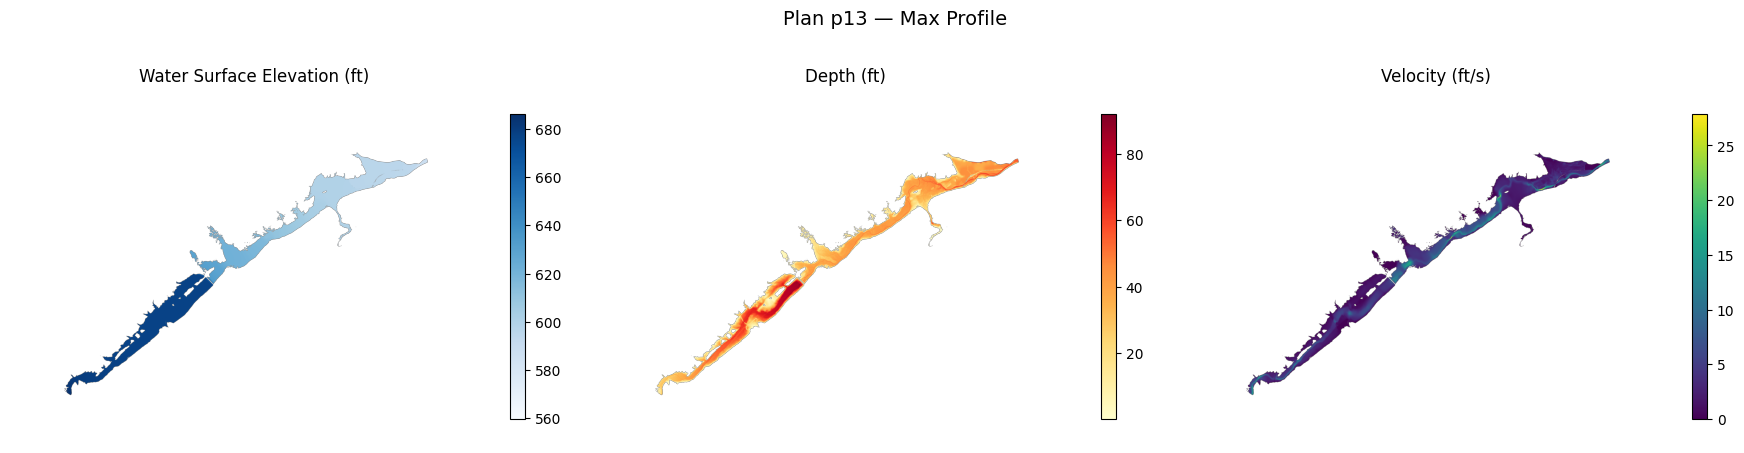

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

CMAP_CONFIG = {
    "wse": {"cmap": "Blues", "label": "Water Surface Elevation (ft)"},
    "depth": {"cmap": "YlOrRd", "label": "Depth (ft)"},
    "velocity": {"cmap": "viridis", "label": "Velocity (ft/s)"},
}

if has_rasterio and results:
    for r in results:
        n_maps = len(r.map_types)
        if n_maps == 0:
            continue

        fig, axes = plt.subplots(1, n_maps, figsize=(6 * n_maps, 5))
        if n_maps == 1:
            axes = [axes]

        for ax, (map_type, paths) in zip(axes, r.map_types.items()):
            tif_path = paths[0]
            with rasterio.open(tif_path) as src:
                data = src.read(1, masked=True)

            cfg = CMAP_CONFIG.get(map_type, {"cmap": "viridis", "label": map_type})
            im = ax.imshow(data, cmap=cfg["cmap"])
            ax.set_title(cfg["label"])
            ax.set_axis_off()
            plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

        fig.suptitle(f"Plan {r.plan_id} — Max Profile", fontsize=14)
        plt.tight_layout()
        plt.show()
elif not results:
    print("No results to display.")
else:
    print("Install rasterio + matplotlib for raster visualization.")

---

## Example 2: Extended Map Types with WGS84 Reprojection

Generate additional map types (Froude, Shear Stress, Depth x Velocity) and reproject to WGS84 for web-compatible rasters.

In [10]:
extended_output = OUTPUT_DIR / "extended_maps"

if plan_hdfs:
    extended_results = generate_result_maps(
        project_path,
        extended_output,
        plans=[f"p{plan_number}"],
        profile="Max",
        wse=False,
        depth=True,
        velocity=False,
        froude=True,
        shear_stress=True,
        depth_x_velocity=True,
        min_depth=0.1,
        ras_version=RAS_VERSION,
        reproject_wgs84=True,
        convert_cog=True,
    )

    print(f"\nGenerated {len(extended_results)} plan result(s):")
    for r in extended_results:
        print(f"  Plan {r.plan_id}:")
        for map_type, paths in r.map_types.items():
            for p in paths:
                size_mb = p.stat().st_size / 1e6 if p.exists() else 0
                print(f"    {map_type}: {p.name} ({size_mb:.1f} MB)")
        if r.errors:
            print(f"    Errors: {r.errors}")
else:
    print("No HDF files available — skipping extended raster generation.")
    extended_results = []


ras2cng map -> <repo>\examples\out\962_cloud_native_cog\extended_maps


Project : BaldEagleDamBrk.prj

Profile : Max

2026-06-11 14:56:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec-ras-install>\7.0\Ras.exe via filesystem (x86)


2026-06-11 14:56:05 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec-ras-install>\6.7 Beta 5\Ras.exe via filesystem (x86)


...

froude: 1 raster(s)

shear_stress: 1 raster(s)

depth_x_velocity: 1 raster(s)

OK Generated 7 raster(s) from 1 plan(s)


Generated 1 plan result(s):
  Plan p13:
    depth: Depth (Max).Terrain50.dtm_20ft_filtered.tif (4.0 MB)
    depth: Depth (Max).Terrain50.dtm_20ft_filtered_filtered.tif (4.0 MB)
    depth: Depth (Max).Terrain50.dtm_20ft_filtered_filtered_filtered.tif (4.0 MB)
    depth: Depth (Max).Terrain50.dtm_20ft_filtered_filtered_filtered_filtered.tif (4.0 MB)
    froude: Froude (Max).Terrain50.dtm_20ft.tif (4.7 MB)
    shear_stress: Shear Stress (Max).Terrain50.dtm_20ft.tif (4.6 MB)
    depth_x_velocity: D _ V (Max).Terrain50.dtm_20ft.tif (4.7 MB)


### Inspect Extended Rasters

Verify the extended rasters have WGS84 CRS and the depth threshold was applied.

In [11]:
if has_rasterio and extended_results:
    for r in extended_results:
        for map_type, paths in r.map_types.items():
            for tif_path in paths:
                if not tif_path.exists():
                    continue
                with rasterio.open(tif_path) as src:
                    print(f"\n{map_type}: {tif_path.name}")
                    print(f"  CRS: {src.crs}")
                    print(f"  Dimensions: {src.width} x {src.height}")

                    data = src.read(1, masked=True)
                    valid = data.compressed()
                    if len(valid) > 0:
                        print(f"  Value range: {valid.min():.3f} — {valid.max():.3f}")
                        print(f"  Valid cells: {len(valid):,}")

                        if map_type == "depth":
                            below_threshold = (valid < 0.1).sum()
                            print(f"  Cells below min_depth (0.1): {below_threshold}")


depth: Depth (Max).Terrain50.dtm_20ft_filtered.tif
  CRS: EPSG:2271
  Dimensions: 6705 x 4852


  Value range: 0.100 — 92.154
  Valid cells: 1,310,186
  Cells below min_depth (0.1): 0

depth: Depth (Max).Terrain50.dtm_20ft_filtered_filtered.tif
  CRS: EPSG:2271
  Dimensions: 6705 x 4852


  Value range: 0.100 — 92.154
  Valid cells: 1,310,186
  Cells below min_depth (0.1): 0

depth: Depth (Max).Terrain50.dtm_20ft_filtered_filtered_filtered.tif
  CRS: EPSG:2271
  Dimensions: 6705 x 4852


  Value range: 0.100 — 92.154
  Valid cells: 1,310,186
  Cells below min_depth (0.1): 0

depth: Depth (Max).Terrain50.dtm_20ft_filtered_filtered_filtered_filtered.tif
  CRS: EPSG:2271
  Dimensions: 6705 x 4852


  Value range: 0.100 — 92.154
  Valid cells: 1,310,186
  Cells below min_depth (0.1): 0

froude: Froude (Max).Terrain50.dtm_20ft.tif
  CRS: EPSG:2271
  Dimensions: 6705 x 4852


  Value range: 0.000 — 43.773
  Valid cells: 1,310,437

shear_stress: Shear Stress (Max).Terrain50.dtm_20ft.tif
  CRS: EPSG:2271
  Dimensions: 6705 x 4852


  Value range: 0.000 — 11.444
  Valid cells: 1,275,899

depth_x_velocity: D _ V (Max).Terrain50.dtm_20ft.tif
  CRS: EPSG:2271
  Dimensions: 6705 x 4852


  Value range: 0.000 — 1303.324
  Valid cells: 1,310,437


### Display Extended Results

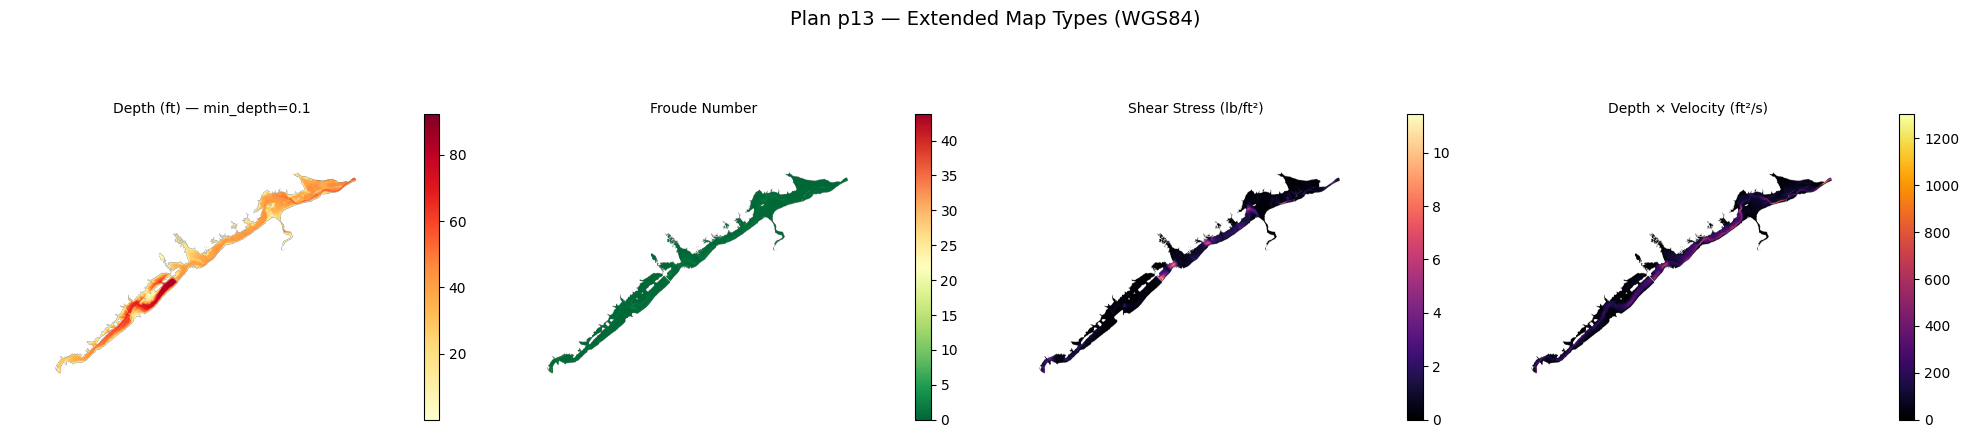

In [12]:
EXTENDED_CMAP = {
    "depth": {"cmap": "YlOrRd", "label": "Depth (ft) — min_depth=0.1"},
    "froude": {"cmap": "RdYlGn_r", "label": "Froude Number"},
    "shear_stress": {"cmap": "magma", "label": "Shear Stress (lb/ft²)"},
    "depth_x_velocity": {"cmap": "inferno", "label": "Depth × Velocity (ft²/s)"},
}

if has_rasterio and extended_results:
    for r in extended_results:
        n_maps = len(r.map_types)
        if n_maps == 0:
            continue

        fig, axes = plt.subplots(1, n_maps, figsize=(5 * n_maps, 5))
        if n_maps == 1:
            axes = [axes]

        for ax, (map_type, paths) in zip(axes, r.map_types.items()):
            tif_path = paths[0]
            if not tif_path.exists():
                ax.text(0.5, 0.5, f"{map_type}\nnot generated", ha="center", va="center")
                continue
            with rasterio.open(tif_path) as src:
                data = src.read(1, masked=True)

            cfg = EXTENDED_CMAP.get(map_type, {"cmap": "viridis", "label": map_type})
            im = ax.imshow(data, cmap=cfg["cmap"])
            ax.set_title(cfg["label"], fontsize=10)
            ax.set_axis_off()
            plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

        fig.suptitle(f"Plan {r.plan_id} — Extended Map Types (WGS84)", fontsize=14)
        plt.tight_layout()
        plt.show()
elif not extended_results:
    print("No extended results to display.")

---

## Understanding Cloud Optimized GeoTIFF (COG)

Cloud Optimized GeoTIFF is a regular GeoTIFF with internal tiling and overview pyramids that enable efficient HTTP range requests. This means a web client can fetch just the tiles it needs without downloading the entire file.

**When `convert_cog=True`**:
1. `generate_result_maps()` first creates standard GeoTIFFs via RasStoreMapHelper.exe
2. Then converts each to COG using `gdal_translate -of COG`
3. Output files get a `_cog` suffix (e.g., `Depth_Max_cog.tif`)

**Requirements**: GDAL must be installed and `gdal_translate` on PATH.

**Benefits of COG**:
- Stream rasters from S3/Azure/GCS without full download
- Built-in overviews for fast zoom-out rendering
- Compatible with QGIS, ArcGIS, leafmap, TiTiler, and other tools
- No special server needed — works from any HTTP host

---

## Output Summary

In [13]:
total_size = 0
file_count = 0

print("Output files:")
for f in sorted(OUTPUT_DIR.rglob("*")):
    if f.is_file():
        size_kb = f.stat().st_size / 1e3
        total_size += size_kb
        file_count += 1
        rel = f.relative_to(OUTPUT_DIR)
        print(f"  {str(rel):50s} {size_kb:>8.1f} KB")

print(f"\nTotal: {file_count} files, {total_size / 1e3:.1f} MB")

Output files:
  core_maps\p13\Depth (Max).Terrain50.dtm_20ft.tif     4029.5 KB
  core_maps\p13\Depth (Max).vrt                           3.4 KB
  core_maps\p13\Velocity (Max).Terrain50.dtm_20ft.tif   4576.9 KB
  core_maps\p13\Velocity (Max).vrt                        3.2 KB
  core_maps\p13\WSE (Max).Terrain50.dtm_20ft.tif       2079.4 KB
  core_maps\p13\WSE (Max).vrt                             3.1 KB
  extended_maps\p13\D _ V (Max).Terrain50.dtm_20ft.tif   4654.5 KB
  extended_maps\p13\D _ V (Max).vrt                       3.1 KB
  extended_maps\p13\Depth (Max).Terrain50.dtm_20ft.tif   4029.5 KB
  extended_maps\p13\Depth (Max).Terrain50.dtm_20ft_filtered.tif   4017.4 KB
  extended_maps\p13\Depth (Max).Terrain50.dtm_20ft_filtered_filtered.tif   4017.4 KB
  extended_maps\p13\Depth (Max).Terrain50.dtm_20ft_filtered_filtered_filtered.tif   4017.4 KB
  extended_maps\p13\Depth (Max).Terrain50.dtm_20ft_filtered_filtered_filtered_filtered.tif   4017.4 KB
  extended_maps\p13\Depth (Max).vrt   

## Key Takeaways

1. **`generate_result_maps()` wraps RasStoreMapHelper.exe** — output matches native HEC-RAS raster generation exactly
2. **11 map types available** — WSE, Depth, Velocity enabled by default; toggle Froude, Shear, DxV, and timing variables as needed
3. **COG conversion** via `convert_cog=True` — produces web-streamable rasters with tiling and overviews
4. **WGS84 reprojection** via `reproject_wgs84=True` — makes rasters compatible with web mapping tools
5. **Depth threshold** via `min_depth=0.1` — filters shallow cells to NoData for cleaner flood maps
6. **MapResult dataclass** provides structured output with `plan_id`, `map_types` dict, and `errors` list

### Python API Quick Reference

```python
from ras2cng import generate_result_maps

# Core rasters with COG conversion
results = generate_result_maps(
    project_path, output_dir,
    wse=True, depth=True, velocity=True,
    convert_cog=True,
)

# Extended types with WGS84 + depth filter
results = generate_result_maps(
    project_path, output_dir,
    froude=True, shear_stress=True, depth_x_velocity=True,
    min_depth=0.1, reproject_wgs84=True, convert_cog=True,
)

# Access results
for r in results:
    print(r.plan_id, r.map_types.keys(), r.errors)
```

### CLI Quick Reference

```bash
# Default: WSE + Depth + Velocity
ras2cng map path/to/project/ ./maps/

# All core types with COG conversion
ras2cng map path/to/project/ ./maps/ --cog

# Extended types with depth filter and WGS84
ras2cng map path/to/project/ ./maps/ \
  --froude --shear-stress --dv \
  --min-depth 0.1 --wgs84 --cog

# Specific plan only
ras2cng map path/to/project/ ./maps/ --plans p01 --cog
```

### Next Steps

- **960_cloud_native_geometry_export.ipynb** — Export geometry to GeoParquet (no HEC-RAS required)
- **961_cloud_native_results_export.ipynb** — Vector results export with DuckDB analytics
- **601_headless_stored_map_generation_rasmapper.ipynb** — Lower-level RasProcess.store_maps() API
- [ras2cng documentation](https://ras2cng.readthedocs.io) — Complete API and CLI reference